## Inteligencja Obliczeniowa w Analizie Danych Cyfrowych

### Projekt 5 - uczenie przez wzmacnianie w przestrzeniach ciągłych

#### Autorzy: Kacper Garwoński, Paweł Gleindek (CWL02, czwartek 11:30)

Tematem piątego miniprojektu była analiza działania algorytmów uczenia przez wzmocnienie (ang. *reinforcement learning*) w grach z przestrzeniami ciągłymi. Do dalszych badań wybraliśmy grę **Climber**, stworzoną przez nas na potrzeby zadania 4.

### Import niezbędnych bibliotek

In [2]:
import io
import zipfile
import torch
import time
import numpy as np
import pygame
import pymunk
import enum
import math
import os
import shutil
import matplotlib.pyplot as plt
from typing import Any
from gymnasium import Env, spaces
from gymnasium.core import ObsType
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback

### Opis implementacji gry

Gra polega na wspinaczce - gracz wbijając kilof oraz wykorzystując wahanie skacze po planszy wspinając się. Jego celem jest dojście na samą górę planszy, do losowo ustawianego punktu. Podczas wspinaczki musi unikać spadających skał. Szerszy opis znajduje się w dalszej części sprawozdania.

#### Klasa `ObjectCategory`

Pomocniczy typ enumeracyjny kodujący obiekty gry:

- gracz: 1
- ściana: 2
- skała: 4
- cel: 8

In [3]:
class ObjectCategory(enum.IntFlag):
    PLAYER = 1
    WALL = 2
    ROCK = 4
    TARGET = 8

#### Klasa `Climber`

Zasadnicza klasa dziedzicząca po `Env` opisująca logikę całej gry. Zawiera następujące funkcje:

- `__init__`: funkcja inicjalizująca (~konstruktor), odpowiada za ustawienie parametrów gry, m.in.:
    - typu renderowania,
    - częstotliwości renderowania spadających kamieni,
    - rozmiaru gracza, kamieni, celu,
    - siły grawitacji,
    - siły zamachu gracza;
- `step`: funkcja realizująca pojedynczą akcję agenta, odpowiada za jego ruch po planszy; w przypadku gry przez agenta RF wylicza nagrodę za ruch na podstawie zdefiniowanych parametrów (np. kara za uderzenie w skałę, bonus za dojście do celu)
- `render`: funkcja odpowiadająca za renderowanie planszy z grą;
- `close`: funkcja obsługująca zamknięcie programu;
- `reset`: funkcja obsługująca reset planszy po sukcesie gracza lub jego porażce w danej turze;
- `_generate_player_pos`: pomocnicza funkcja losowo generująca pozycję gracza na początku tury;
- `_generate_target_pos`: pomocnicza funkcja losowo generująca pozycję celu na początku tury;
- `_generate_rock_pos`: pomocnicza funkcja generująca losowo kolejne położenia spadających skał;
- `_create_target`: pomocnicza funkcja definiująca wygląd i zachowanie agenta na podstawie zadanych parametrów gry;
- `_create_player`: pomocnicza funkcja definiująca wygląd i zachowanie celu (na podstawie zadanych parametrów gry);
- `_create_walls`: pomocnicza funkcja definiująca ściany środowiska/planszy, po jakiej porusza się agent;
- `_create_pickaxe`: pomocnicza funkcja definiująca wygląd i zachowanie kilofa gracza na podstawie;
- `_create_rock`: pomocnicza funkcja definiująca wygląd i zachowanie spadającej skały na podstawie;
- `_get_obs`: kluczowa z punktu widzenia agenta funkcja, która zwraca mu stan jego obserwacji, m.in. jego pozycję, stan wbicia kilofa, wychylenie;
- `_rock_collision`: funkcja obsługująca zdarzenie polegające na zderzeniu agenta ze skałą;
- `_target_collision`: funkcja obsługująca zwycięstwo gracza (dojście do celu);

![Game Screen](game_screen.jpg "Widok gry")

In [4]:
def _get_relative_pos(body1: pymunk.Body, body2: pymunk.Body) -> tuple[float, float]:
    return  body1.position.x - body2.position.x, body1.position.y - body2.position.y

class Climber(Env):
    """
    Climber game environment for gymnasium. Observation space is continuous,
    same as action space. Number of rays used in ray-casting is hardcoded and
    is 12. Utilizes pymunk as the physics engine.
    """

    metadata = {
        'render_modes': ['human'],
        'fps' : 60,
        'map_settings' : {
            'width': 800,
            'height': 800,
        }
    }

    def __init__(self, render_mode = None, rock_every: float = 0, player_size = 15,
                 rock_size = 15, target_size = 15, rock_mass = 0.75, gravity = 450,
                 pickaxe_length = 50, swing_power = 650):
        self.target_body = None
        self.player_body = None
        self.draw_options = None
        self.clock = None
        self.window = None
        self.space = None
        self.walls = None
        self.target = None
        self.player = None
        self.joint = None
        self.prev_pos = None

        assert rock_every > 0

        assert render_mode in self.metadata['render_modes'] or render_mode is None

        self.render_mode = render_mode
        self.rock_every = rock_every

        self.action_space = spaces.Box(low=-1, high=1, shape=(2,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(22,),
                                            dtype=np.float32)

        self.hit_rock = False
        self.hit_target = False
        self.curr_step = 0
        self.max_steps = 10_000
        self.pickaxe_length = pickaxe_length
        self.gravity_level = gravity
        self.swing_power_multiplier = swing_power
        self.target_size = target_size
        self.player_size = player_size
        self.rock_size = rock_size
        self.rock_mass = rock_mass
        self.ray_distance = 200


    def step(self, action):
        pickaxe_val = action[0]
        player_force = action[1]

        self.prev_pos = self.player.body.position

        if pickaxe_val > 0.5 and self.joint is None:
            self.joint = self._create_pickaxe()
            self.space.add(self.joint)
        elif pickaxe_val < -0.5 and self.joint:
            self.space.remove(self.joint)
            self.joint = None

        force_x = player_force * self.swing_power_multiplier
        if self.joint is not None:
            self.player.body.apply_force_at_local_point((force_x, 0), (0, 0))
        else:
            self.player.body.apply_force_at_local_point((force_x * 0.2, 0), (0, 0))

        game_fps = self.metadata['fps']

        self.space.step(1 / game_fps)
        self.curr_step += 1
        obs = self._get_obs()

        reward = 0.0
        terminated = False
        truncated = False
        info = {"is_success": False}

        reward -= 0.001

        if self.hit_rock:
            reward -= 2.0
            terminated = True
            info["is_success"] = False

        elif self.hit_target:
            reward += 20.0
            terminated = True
            info["is_success"] = True

        elif self.curr_step >= self.max_steps:
            truncated = True

        else:
            prev_dist = np.linalg.norm(self.prev_pos - self.target.body.position)
            curr_dist = np.linalg.norm(self.player.body.position
                                       - self.target.body.position)

            reward += (prev_dist - curr_dist) * 0.1
            reward += (self.prev_pos.y - self.player.body.position.y) * 0.05

            if self.joint is not None:
                reward += 0.01

            reward += (self.player.body.position.y / 1000) * 0.01
            reward -= abs(self.player.body.angular_velocity) * 0.05

        if self.curr_step % self.rock_every == 0:
            rock, rock_body = self._create_rock()
            self.space.add(rock_body)
            self.space.add(rock)

        return obs, reward, terminated, truncated, info

    def render(self):
        if self.render_mode != 'human':
            return

        if self.window is None:
            pygame.init()
            pygame.display.init()
            width = self.metadata['map_settings']['width']
            height = self.metadata['map_settings']['height']
            self.window = pygame.display.set_mode((width, height))
            self.clock = pygame.time.Clock()

            self.player_img_base = (pygame.image.load("character_green_walk_a.png")
                                    .convert_alpha())
            self.player_img_base = pygame.transform.scale(self.player_img_base,
                                                          (self.player_size * 2,
                                                           self.player_size * 2))

            self.rock_img_base = pygame.image.load("block_fall.png").convert_alpha()
            self.rock_img_base = pygame.transform.scale(self.rock_img_base,
                                                        (self.rock_size * 2,
                                                         self.rock_size * 2))

            self.target_img_base = pygame.image.load("ladybug_fly.png").convert_alpha()
            self.target_img_base = pygame.transform.scale(self.target_img_base,
                                                          (self.target_size * 2,
                                                           self.target_size * 2))

        self.window.fill((255, 255, 255))

        for wall in self.walls:
            p1 = (int(wall.a.x), int(wall.a.y))
            p2 = (int(wall.b.x), int(wall.b.y))
            pygame.draw.line(self.window, (50, 50, 50), p1, p2, int(wall.radius * 2))

        if self.joint is not None:
            p1 = (int(self.joint.anchor_a.x), int(self.joint.anchor_a.y))
            p2 = (int(self.player_body.position.x), int(self.player_body.position.y))
            pygame.draw.line(self.window, (139, 69, 19), p1, p2, 4)

        p_angle = math.degrees(-self.player_body.angle)
        p_img_rotated = pygame.transform.rotate(self.player_img_base, p_angle)
        p_rect = p_img_rotated.get_rect(center=(self.player_body.position.x,
                                                self.player_body.position.y))
        self.window.blit(p_img_rotated, p_rect.topleft)

        t_rect = self.target_img_base.get_rect(center=(self.target_body.position.x,
                                                       self.target_body.position.y))
        self.window.blit(self.target_img_base, t_rect.topleft)

        for shape in self.space.shapes:
            if shape.collision_type == ObjectCategory.ROCK:
                r_angle = math.degrees(-shape.body.angle)
                r_img_rotated = pygame.transform.rotate(self.rock_img_base, r_angle)
                r_rect = r_img_rotated.get_rect(center=(shape.body.position.x,
                                                        shape.body.position.y))
                self.window.blit(r_img_rotated, r_rect.topleft)

        pygame.display.flip()
        self.clock.tick(self.metadata['fps'])

    def close(self):
        if self.window is not None:
            pygame.quit()
            self.window = None
            self.clock = None

    def reset(self, *, seed: int | None = None, options: dict[str, Any] | None = None, ) -> tuple[ObsType, dict[str, Any]]:
        Env.reset(self, seed=seed, options=options)

        self.space = pymunk.Space()

        self.target, self.target_body = self._create_target()
        self.player, self.player_body = self._create_player()
        self.prev_pos = self.player.body.position
        self.walls = self._create_walls()
        self.joint = None

        self.space.add(self.player, self.player_body, self.target, self.target_body,
                       *self.walls)
        self.space.gravity = (0, self.gravity_level)
        self.space.on_collision(ObjectCategory.PLAYER, ObjectCategory.ROCK,
                                begin = self._rock_collision)
        self.space.on_collision(ObjectCategory.PLAYER, ObjectCategory.TARGET,
                                begin = self._target_collision)

        self.curr_step = 0
        self.hit_rock = False
        self.hit_target = False

        self.space.gravity = (0, self.gravity_level)
        self.space.damping = 0.7

        return self._get_obs(), {}

    def _generate_player_pos(self) -> tuple[int, int]:
        rand_with_min = 50
        rand_with_max = max(self.metadata['map_settings']['width'] - 50, 100)

        player_height_pos = max(self.metadata['map_settings']['height'] - 50, 100)

        return (int(self.np_random.integers(low=rand_with_min, high=rand_with_max)),
                player_height_pos)

    def _generate_target_pos(self) -> tuple[int, int]:
        rand_with_min = 50
        rand_with_max = max(self.metadata['map_settings']['width'] - 50, 100)

        target_height_pos = 50

        return (int(self.np_random.integers(low=rand_with_min, high=rand_with_max)),
                target_height_pos)

    def _generate_rock_pos(self) -> tuple[int, int]:
        rand_with_min = 0
        rand_with_max = max(self.metadata['map_settings']['width'], 100)

        rock_height_pos = 50

        return (int(self.np_random.integers(low=rand_with_min, high=rand_with_max)),
                rock_height_pos)

    def _create_target(self) -> tuple[pymunk.Circle, pymunk.Body]:
        target_body = pymunk.Body(body_type=pymunk.Body.STATIC)
        target_body.position = self._generate_target_pos()
        target = pymunk.Circle(target_body, radius=self.target_size)
        target.filter = pymunk.ShapeFilter(categories=ObjectCategory.TARGET)
        target.sensor = True
        target.color = (0, 0, 0, 0)
        target.collision_type = ObjectCategory.TARGET

        return target, target_body

    def _create_player(self) -> tuple[pymunk.Circle, pymunk.Body]:
        player_body = pymunk.Body(mass=1,
                                  moment=pymunk.moment_for_circle(1, 0,
                                                                  self.player_size),
                                  body_type=pymunk.Body.DYNAMIC
                                  )

        player_body.position = self._generate_player_pos()

        player = pymunk.Circle(player_body, radius=self.player_size)
        player.color = (0, 0, 0, 0)

        player.filter = pymunk.ShapeFilter(categories=ObjectCategory.PLAYER)
        player.collision_type = ObjectCategory.PLAYER

        return player, player_body

    def _create_walls(self) -> list[pymunk.Segment]:
        map_height = self.metadata['map_settings']['height']
        map_width = self.metadata['map_settings']['width']

        floor = pymunk.Segment(self.space.static_body, (0, map_height),
                               (map_width, map_height), 10)
        ceiling = pymunk.Segment(self.space.static_body, (0, 0),
                                 (map_width, 0), 10)
        left_wall = pymunk.Segment(self.space.static_body, (0, 0),
                                   (0, map_height), 10)
        right_wall = pymunk.Segment(self.space.static_body, (map_width, 0),
                                    (map_width, map_height), 10)

        walls = [floor, ceiling, left_wall, right_wall]

        for wall in walls:
            wall.friction = 1.0
            wall.elasticity = 0.2
            wall.filter = pymunk.ShapeFilter(categories=ObjectCategory.WALL)

        return walls

    def _create_pickaxe(self) -> pymunk.PinJoint:
        pos = self.player.body.position
        anchor_point = (pos.x, pos.y - self.pickaxe_length)

        joint = pymunk.PinJoint(
            self.space.static_body,
            self.player.body,
            anchor_point,
            (0, 0)
        )
        return joint

    def _create_rock(self) -> tuple[pymunk.Circle, pymunk.Body]:
        rock_body = pymunk.Body(mass=self.rock_mass,
                                moment=pymunk.moment_for_circle(self.rock_mass,
                                                                0, self.rock_size),
                                body_type=pymunk.Body.DYNAMIC
                                )

        rock_body.position = self._generate_rock_pos()

        rock = pymunk.Circle(rock_body, radius=self.rock_size)
        rock.color = (0, 0, 0, 0)
        rock.filter = pymunk.ShapeFilter(categories=ObjectCategory.ROCK)
        rock.collision_type = ObjectCategory.ROCK

        return rock, rock_body

    def _get_obs(self):
        obs = np.zeros(22, dtype=np.float32)

        obs[0] = self.player.body.position.x / 800.0
        obs[1] = self.player.body.position.y / 1000.0

        obs[2] = self.player.body.velocity.x / 500.0
        obs[3] = self.player.body.velocity.y / 500.0

        dx, dy = _get_relative_pos(self.player.body, self.target.body)
        obs[4] = dx / 800.0
        obs[5] = dy / 1000.0

        shape_filter = pymunk.ShapeFilter(categories=ObjectCategory.ROCK)
        rays = 12
        angle = 360 / rays

        for i in range(rays):
            rad_deg = np.deg2rad(angle * i)

            dx = np.cos(rad_deg) * self.ray_distance
            dy = np.sin(rad_deg) * self.ray_distance

            start_p = self.player.body.position
            end_p = (start_p.x + dx, start_p.y + dy)

            query = self.space.segment_query_first(start_p, end_p, 1, shape_filter)

            if query is None:
                obs[6 + i] = 1.0
            else:
                obs[6 + i] = query.alpha

        obs[18] = 1.0 if self.joint is not None else 0.0

        angle = self.player.body.angle
        obs[19] = np.sin(angle)
        obs[20] = np.cos(angle)

        obs[21] = self.player.body.angular_velocity / 10.0

        return obs

    def _rock_collision(self, arbiter, space, data):
        self.hit_rock = True
        print("GAME LOST - hit_rock")

    def _target_collision(self, arbiter, space, data):
        self.hit_target = True
        print("GAME WON - hit_target")

#### Funkcja `play_climber`

Funkcja uruchamiająca i wyświetlająca rozgrywkę

In [5]:
def play_climber():
    env = Climber(render_mode='human', rock_every=110, target_size=8,
                  rock_size=25, gravity=500, swing_power=600, pickaxe_length=60)
    obs, info = env.reset()
    env.render()
    pickaxe_active = False
    running = True

    print("Sterowanie:")
    print("- SPACJA: Wbij/Wyjmij kilof (Przełącznik)")
    print("- STRZAŁKA W LEWO: Siła w lewo")
    print("- STRZAŁKA W PRAWO: Siła w prawo")
    print("- ZAMKNIĘCIE OKNA: Wyjście")

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_SPACE:
                    pickaxe_active = not pickaxe_active

        keys = pygame.key.get_pressed()
        force = 0.0
        if keys[pygame.K_LEFT]:
            force = -1.0
        if keys[pygame.K_RIGHT]:
            force = 1.0

        pickaxe_val = 1.0 if pickaxe_active else -1.0

        action = np.array([pickaxe_val, force], dtype=np.float32)

        obs, reward, terminated, truncated, info = env.step(action)

        env.render()

        if terminated or truncated:
            status = "WYGRANA!" if info.get("is_success") else "PORAŻKA (Kamień)"
            if truncated:
                status = "KONIEC CZASU"

            print(f"Koniec epizodu! Status: {status} | Ostatnia nagroda: {reward:.2f}")

            obs, info = env.reset()
            pickaxe_active = False

    env.close()

#### Gra

Uruchamiając poniższą komórkę można rozpocząć rozgrywkę i samemu zmierzyć się z wyzwaniem wspinaczki!

**Sterowanie**:

- spacja: wbij/wyjmij kilof (przełącznik)
- strzałka w lewo: siła w lewo
- strzałka w prawo: siła w prawo
- zamknięcie okna: wyjście

In [6]:
play_climber()

Sterowanie:
- SPACJA: Wbij/Wyjmij kilof (Przełącznik)
- STRZAŁKA W LEWO: Siła w lewo
- STRZAŁKA W PRAWO: Siła w prawo
- ZAMKNIĘCIE OKNA: Wyjście
GAME LOST - hit_rock
Koniec epizodu! Status: PORAŻKA (Kamień) | Ostatnia nagroda: -2.00
GAME WON - hit_target
Koniec epizodu! Status: WYGRANA! | Ostatnia nagroda: 20.00


### Algorytm PPO

Do treningu agenta przechodzącego grę Climber wybrano algorytm PPO (ang. *Proximal Policy Optimization*, co można przetłumaczyć jako "Bliższa Optymalizacja Polityki"). Jest to obecnie standardowy, popularny algorytm *state-of-the-art* w uczeniu przez wzmocnienie, używany do optymalizacji polityk w stabilny i wydajny sposób.

**Komponenty:**

- **funkcja celu**: korzysta z funkcji polityki i funkcji wartości, celem maksymalizacji oczekiwanej skumulowanej nagrody,
- **optymalizacja zasad**: ogranicza aktualizację polityki, celem zapobiegnięcia odbieganiu od starej polityki.

**Cechy charakterystyczne:**

- stabilność,
- wydajność próbek,
- prostota.

PPO bardzo dobrze sprawdza się w złożonych środowiskach z ciągłymi przestrzeniami akcji i stanów.

#### Wykonane eksperymenty z AI

W ramach projektu zostały wykonane analizy znaczenia hiperparametrów wybranego algorytmu (PPO). Narysowano krzywe uczenia dla 3 zestawów parametrów:

- set 1 (domyślny, zbalansowany): `learning_rate=3e-4, n_steps=2048, batch_size=64`,
- set 2 (szybki, agresywny): `learning_rate = 1e-3, n_steps = 1024, batch_size = 128`,
- set 3 (wolny, stabilny): `learning_rate = 1e-4, n_steps = 4096, batch_size = 256`;

krzywe te obrazują średnią nagrodę i odchylenie standardowe obliczone na podstawie 10 uruchomień algorytmu w tych samych warunkach, z wyjątkiem różnej inicjalizacji. W ramach każdego uruchomienia przeprowadzone było 50 000 kroków czasowych.

In [6]:
def make_env(env_seed):
    def _init():
        env = Climber(rock_every=200)
        env.reset(seed=env_seed)
        return Monitor(env)
    return _init

In [7]:
class TimeTrackingCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.start_time = None
        self.step_counts = 0

    def _on_training_start(self) -> None:
        self.start_time = time.time()
        self.step_counts = 0

    def _on_step(self) -> bool:
        self.step_counts = self.num_timesteps
        return True

    def _on_training_end(self) -> None:
        end_time = time.time()
        total_duration = end_time - self.start_time

        if self.step_counts > 0:
            time_per_step = total_duration / self.step_counts
            print(f"\n[CZAS] Łączny czas uczenia (50k kroków): {total_duration:.2f} sekund")
            print(f"[CZAS] Średni czas jednego kroku środowiska: {time_per_step * 1000:.4f} ms")

In [8]:
def run_experiment():
    total_timesteps = 50_000
    n_runs = 10
    num_cpu = 4
    eval_freq = max(2500 // num_cpu, 1)
    n_eval_episodes = 5

    hyperparams_sets = [
        {"name": "Set_1_Default", "lr": 3e-4, "n_steps": 2048, "batch_size": 64},
        {"name": "Set_2_Aggressive", "lr": 1e-3, "n_steps": 1024, "batch_size": 128},
        {"name": "Set_3_Stable", "lr": 1e-4, "n_steps": 4096, "batch_size": 256},
    ]

    all_results = {}

    log_dir = "./tmp_eval_logs"
    os.makedirs(log_dir, exist_ok=True)

    for hp in hyperparams_sets:
        print(f"\n--- Rozpoczynam testy dla: {hp['name']} ---")
        runs_mean_rewards = []

        for seed in range(n_runs):
            print(f"Uruchomienie {seed + 1}/{n_runs}...")

            env = SubprocVecEnv([make_env(seed + i) for i in range(num_cpu)])
            eval_env = DummyVecEnv([lambda: Monitor(Climber(rock_every=200))])

            run_log_dir = os.path.join(log_dir, f"{hp['name']}_seed_{seed}")
            os.makedirs(run_log_dir, exist_ok=True)

            time_callback = TimeTrackingCallback()
            eval_callback = EvalCallback(
                eval_env,
                best_model_save_path=None,
                log_path=run_log_dir,
                eval_freq=eval_freq,
                n_eval_episodes=n_eval_episodes,
                deterministic=True,
                render=False,
                verbose=0
            )

            model = PPO(
                "MlpPolicy",
                env,
                learning_rate=hp["lr"],
                n_steps=hp["n_steps"],
                batch_size=hp["batch_size"],
                seed=seed,
                verbose=0
            )

            model.learn(total_timesteps=total_timesteps, callback=[eval_callback, time_callback])

            eval_data = np.load(os.path.join(run_log_dir, "evaluations.npz"))
            x_timesteps = eval_data["timesteps"]

            mean_rewards_per_eval = np.mean(eval_data["results"], axis=1)
            runs_mean_rewards.append(mean_rewards_per_eval)

            env.close()
            eval_env.close()
            del model

        all_results[hp['name']] = {
            "x": x_timesteps,
            "y_mean": np.mean(runs_mean_rewards, axis=0),
            "y_std": np.std(runs_mean_rewards, axis=0)
        }

    time.sleep(2)
    try:
        shutil.rmtree(log_dir)
    except PermissionError:
        print(f"\n[Info] Nie udało się usunąć folderu {log_dir} – zostanie wyczyszczony przy następnym uruchomieniu.")

    plt.figure(figsize=(10, 6))

    colors = ['blue', 'orange', 'green']

    for (name, data), color in zip(all_results.items(), colors):
        plt.plot(data["x"], data["y_mean"], label=f"{name} (Mean)", color=color)
        plt.fill_between(
            data["x"],
            data["y_mean"] - data["y_std"],
            data["y_mean"] + data["y_std"],
            color=color,
            alpha=0.2,
            label=f"{name} (Std Dev)"
        )

    plt.title("Krzywe Uczenia PPO dla środowiska Climber (Średnia z 10 uruchomień)")
    plt.xlabel("Liczba Kroków Czasowych")
    plt.ylabel("Średnia Nagroda (Reward)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


--- Rozpoczynam testy dla: Set_1_Default ---
Uruchomienie 1/10...
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST

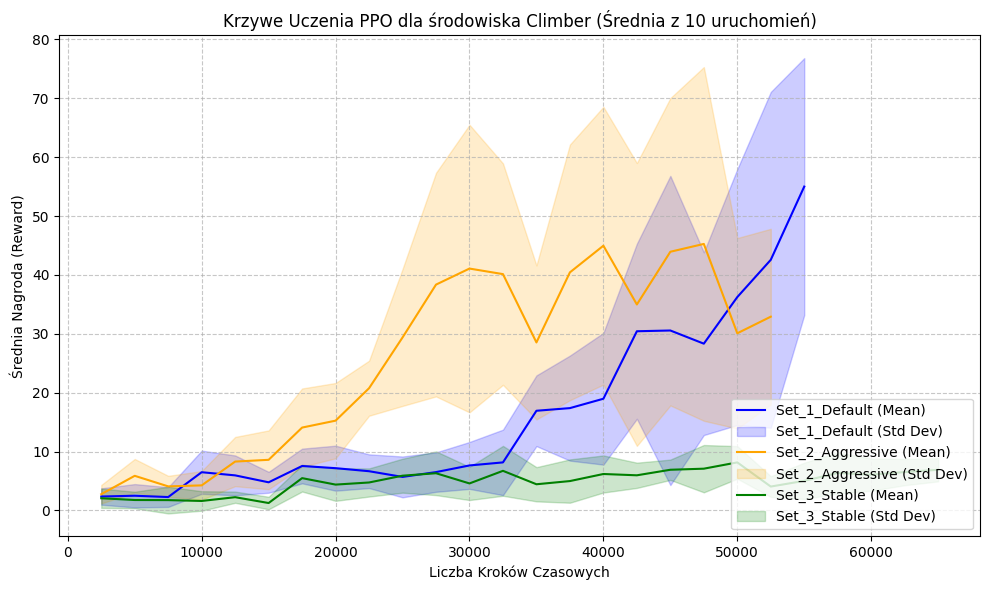

In [15]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="stable_baselines3")
run_experiment()

#### Komentarz

1. Najsłabsze wyniki uzyskał model oparty o hiperparametry gwarantujące powolną, stabilną naukę (set 3: `learning_rate = 1e-4, n_steps = 4096, batch_size = 256`). Widać, że na przestrzeni 50 000 kroków czasowych średnia nagroda wzrosła bardzo nieznacznie, tylko raz zbliżając się do poziomu 10. Bardzo niskie było także odchylenie standardowe, co potwierdza stabilność uczenia.
    - średni łączny czas uczenia (50k kroków): 108.40 s
    - średni czas jednego kroku środowiska: 2.1681 ms
2. 'Agresywny' zestaw hiperparametrów (set 2: `learning_rate = 1e-3, n_steps = 1024, batch_size = 128`), nastawiony na większą eksploatację przestrzeni gry, bardzo szybko zaczął uzyskiwać wyższe wyniki nagrody. Odbyło się to jednak kosztem bardzo wysokiego poziomu odchylenia standardowego i dużych fluktuacji wartości średniej nagrody.
    - średni łączny czas uczenia (50k kroków): 119.23 s
    - średni czas jednego kroku środowiska: 2.3845 ms
3. Najlepsze wyniki uzyskiwał model zbalansowany (set 1: `learning_rate=3e-4, n_steps=2048, batch_size=64`). Początkowo średnia nagroda rosła powoli, jednak po ok. 30 000 kroków zaczęła ona gwałtownie rosnąć, osiągając najwyższy ze wszystkich modeli wynik ok. 55. Pociągnęło to za sobą wzrost odchylenia standardowego.
    - średni łączny czas uczenia (50k kroków): 133.88 s
    - średni czas jednego kroku środowiska: 2.6777 ms

### Wyniki najlepszego agenta

Poniższa sekcja umożliwia uruchomienie gry najlepszego z wytrenowanych agentów AI w trybie z wyłączonym trybem eksploracji (agent działa wybierając deterministycznie najlepsze akcje).

In [9]:
def test_best_curriculum(det, rock_every=110, player_size=15, rock_size=15,
                          target_size=15, rock_mass=0.75, gravity=450,
                          pickaxe_length=50, swing_power=650):

    env = Climber(render_mode='human', rock_every=rock_every, player_size=player_size,
                  rock_size=rock_size, target_size=target_size, rock_mass=rock_mass,
                  gravity=gravity, pickaxe_length=pickaxe_length, swing_power=swing_power)
    venv = DummyVecEnv([lambda: env])

    try:
        venv = VecNormalize.load("vec_normalize.pkl", venv)
        venv.training = False
        venv.norm_reward = False
    except Exception as e:
        print(f"Błąd ładowania: {e}")
        return

    try:
        model = PPO.load("ppo_climber_model", env=venv)
    except:
        model = PPO("MlpPolicy", venv, verbose=1)

        model_path = "ppo_climber_model.zip"

        try:
            with zipfile.ZipFile(model_path, 'r') as archive:
                with archive.open('policy.pth') as weights_file:
                    buffer = io.BytesIO(weights_file.read())
                    state_dict = torch.load(buffer, map_location="cpu",
                                            weights_only=False)

                    model.policy.load_state_dict(state_dict)
                    print("Wagi wstrzyknięte pomyślnie!")
        except Exception as e:
            print(f"Błąd podczas ręcznego ładowania: {e}")
            return

    obs = venv.reset()
    env.render()
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        if not running:
            break

        action, _states = model.predict(obs, deterministic=det)
        obs, reward, dones, info = venv.step(action)

        env.render()

    env.close()

In [9]:
test_best_curriculum(True)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target



### 1. Cel bieżącego eksperymentu

Obecny etap projektu skupia się na analizie wpływu architektury sieci neuronowej agenta na efektywność procesu uczenia ze wzmocnieniem. Po zbadaniu różnych zestawów hiperparametrów w poprzednim kroku, obecnie testowane są modyfikacje samej struktury w algorytmie PPO. Celem jest sprawdzenie, czy zmiana głębokości, szerokości warstw oraz funkcji aktywacji wpłynie na stabilność i końcowy wynik agenta.

### 2. Wybór hiperparametrów

Jako wybór hiperparametrów, sugerowano się poprzednim eksperymentem, dlatego obecnie używany zestaw hiperparametrów jest tym, który był najlepsze spośród 3 zestawów z poprzedniego ćwiczenia:
* `learning_rate` = 3e-4
* `n_steps` = 2048
* `batch_size` = 64

Każda z architektur wykorzystuje ten same stały zestaw hiperparametrów dając, mniej więcej, równe szanse dla wszystkich architektur

### 3. Charakterystyka badanych architektur

Z uwagi na wymiary środowiska przestrzeni ciągłej, każda z architektur dzieli tę samą strukturę wejścia i wyjścia:
* **Wejście sieci:** 22 neurony (odpowiadające wektorowi obserwacji ze środowiska).
* **Wyjście sieci Aktora (`pi`):** 4 neurony (generujące parametry rozkładu dla akcji: 2 neurony dla średniej $\mu$ i 2 neurony dla odchylenia standardowego $\sigma$ obu akcji).
* **Wyjście sieci Krytyka (`vf`):** 1 neuron (estymata wartości stanu, czyli przewidywana skumulowana nagroda).

Do testów wybrano trzy zróżnicowane poz względem idei sieci:

#### Architektura 1: Domyślna i zbalansowana
* **Funkcja aktywacji:** `Tanh`
* **Warstwy ukryte (Aktor):** `[64, 64]`
* **Warstwy ukryte (Krytyk):** `[64, 64]`
* **Opis:** Klasyczna, płytka struktura domyślna. Zastosowanie funkcji tangensa hiperbolicznego zapewnia gładkie przejścia gradientów. Zachowuje balans między szybkością obliczeń a pojemnością sieci dla prostszych problemów.

#### Architektura 2: Głęboka i pojemna
* **Funkcja aktywacji:** `ReLU`
* **Warstwy ukryte (Aktor):** `[256, 256, 256]`
* **Warstwy ukryte (Krytyk):** `[256, 256, 256]`
* **Opis:** Sieć znacznie szersza i głębsza, wykorzystująca standardową funkcję ReLU. Posiada znacznie większą pojemność reprezentacyjną, co pozwala jej wyłapywać bardziej złożone zachowania. Wiąże się to jednak ze zwiększonym ryzykiem przeuczenia oraz dłuższym czasem przetwarzania pojedynczego kroku.

#### Architektura 3: Asymetryczna (eksperymentalna)
* **Funkcja aktywacji:** `LeakyReLU`
* **Warstwy ukryte (Aktor):** `[128, 64]`
* **Warstwy ukryte (Krytyk):** `[256, 128]`
* **Opis:** Wariant asymetryczny z funkcją LeakyReLU, która zapobiega problemowi "martwych neuronów". W tej architekturze sieć Krytyka jest celowo większa od sieci Aktora. Założeniem jest ułatwienie dokładnej estymacji wartości stanu złożonego środowiska, przy jednoczesnym zachowaniu prostszej, mniej podatnej na zaszumienia polityki dla samego Aktora.

In [10]:
import os
import time
import shutil
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

def run_experiment_archs():
    total_timesteps = 50_000
    n_runs = 10
    num_cpu = 4
    eval_freq = max(2500 // num_cpu, 1)
    n_eval_episodes = 5

    architecture_sets = [
        {
            "name": "Arch_1_Default_Tanh",
            "policy_kwargs": dict(activation_fn=nn.Tanh, net_arch=dict(pi=[64, 64], vf=[64, 64]))
        },
        {
            "name": "Arch_2_Deep_ReLU",
            "policy_kwargs": dict(activation_fn=nn.ReLU, net_arch=dict(pi=[256, 256, 256], vf=[256, 256, 256]))
        },
        {
            "name": "Arch_3_Asymmetric_LeakyReLU",
            "policy_kwargs": dict(activation_fn=nn.LeakyReLU, net_arch=dict(pi=[128, 64], vf=[256, 128]))
        }
    ]

    all_results = {}
    log_dir = "./tmp_eval_logs"
    os.makedirs(log_dir, exist_ok=True)

    global_best_reward = -np.inf
    final_best_model_path = "./best_climber_model"

    for arch in architecture_sets:
        print(f"\n--- Rozpoczynam testy dla: {arch['name']} ---")
        runs_mean_rewards = []

        for seed in range(n_runs):
            print(f"Uruchomienie {seed + 1}/{n_runs}...")

            env = SubprocVecEnv([make_env(seed + i) for i in range(num_cpu)])
            eval_env = DummyVecEnv([lambda: Monitor(Climber(rock_every=200))])

            run_log_dir = os.path.join(log_dir, f"{arch['name']}_seed_{seed}")
            os.makedirs(run_log_dir, exist_ok=True)

            time_callback = TimeTrackingCallback()
            eval_callback = EvalCallback(
                eval_env,
                best_model_save_path=run_log_dir,
                log_path=run_log_dir,
                eval_freq=eval_freq,
                n_eval_episodes=n_eval_episodes,
                deterministic=True,
                render=False,
                verbose=0
            )

            model = PPO(
                "MlpPolicy",
                env,
                learning_rate=3e-4,
                n_steps=2048,
                batch_size=64,
                policy_kwargs=arch["policy_kwargs"],
                seed=seed,
                verbose=0
            )

            model.learn(total_timesteps=total_timesteps, callback=[eval_callback, time_callback])

            if eval_callback.best_mean_reward > global_best_reward:
                global_best_reward = eval_callback.best_mean_reward
                best_saved_model = os.path.join(run_log_dir, "best_model.zip")
                if os.path.exists(best_saved_model):
                    shutil.copy(best_saved_model, final_best_model_path + ".zip")

            eval_data = np.load(os.path.join(run_log_dir, "evaluations.npz"))
            x_timesteps = eval_data["timesteps"]

            mean_rewards_per_eval = np.mean(eval_data["results"], axis=1)
            runs_mean_rewards.append(mean_rewards_per_eval)

            env.close()
            eval_env.close()
            del model

        all_results[arch['name']] = {
            "x": x_timesteps,
            "y_mean": np.mean(runs_mean_rewards, axis=0),
            "y_std": np.std(runs_mean_rewards, axis=0)
        }

    time.sleep(2)
    try:
        shutil.rmtree(log_dir)
    except PermissionError:
        print(f"\n[Info] Nie udało się usunąć folderu {log_dir} – zostanie wyczyszczony przy następnym uruchomieniu.")

    plt.figure(figsize=(10, 6))
    colors = ['blue', 'orange', 'green']

    for (name, data), color in zip(all_results.items(), colors):
        plt.plot(data["x"], data["y_mean"], label=f"{name} (Mean)", color=color)
        plt.fill_between(
            data["x"],
            data["y_mean"] - data["y_std"],
            data["y_mean"] + data["y_std"],
            color=color,
            alpha=0.2
        )

    plt.title("Krzywe Uczenia PPO - Porównanie Architektur (Średnia z 10 uruchomień)")
    plt.xlabel("Liczba Kroków Czasowych")
    plt.ylabel("Średnia Nagroda (Reward)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    print(f"\n[Info] Najlepszy model ze wszystkich testów zapisano jako: {final_best_model_path}.zip (Nagroda: {global_best_reward})")


--- Rozpoczynam testy dla: Arch_1_Default_Tanh ---
Uruchomienie 1/10...


C:\Users\kacpe\PycharmProjects\inteligencja_obliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
C:\Users\kacpe\PycharmProjects\inteligencja_obliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.subproc_vec_env.SubprocVecEnv object at 0x0000024A9797B4D0> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x0000024A979C9010>
  warnings.warn("

GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - h

C:\Users\kacpe\PycharmProjects\inteligencja_obliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.subproc_vec_env.SubprocVecEnv object at 0x0000024AAA6A1DD0> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x0000024AA0E148D0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - h

...

GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - h

C:\Users\kacpe\PycharmProjects\inteligencja_obliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.subproc_vec_env.SubprocVecEnv object at 0x0000024A9F9CDB90> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x0000024A9F985990>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - h

C:\Users\kacpe\PycharmProjects\inteligencja_obliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.subproc_vec_env.SubprocVecEnv object at 0x0000024A9F46F990> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x0000024AAA69ED90>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - h

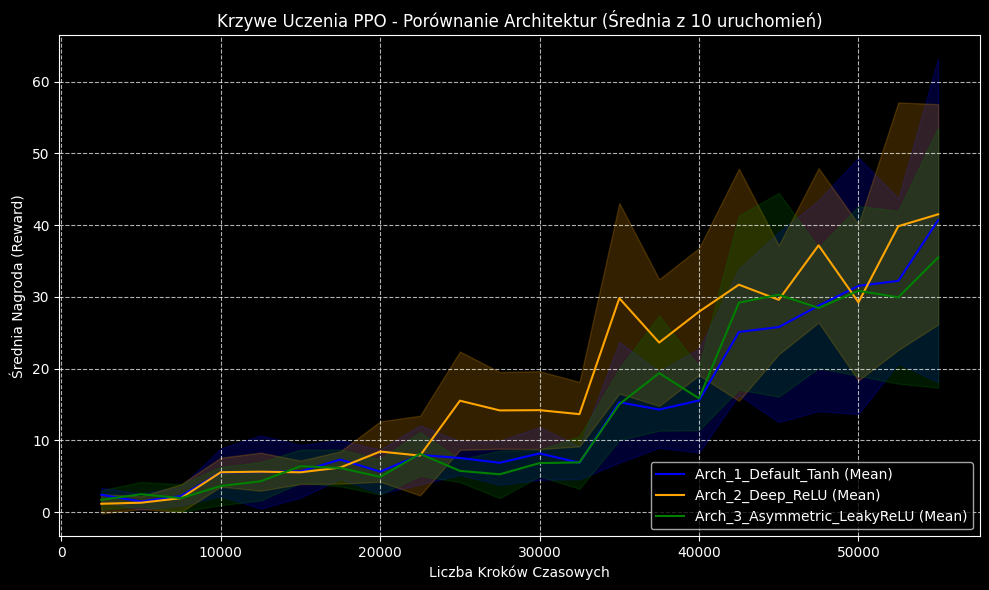


[Info] Najlepszy model ze wszystkich testów zapisano jako: ./best_climber_model.zip (Nagroda: 89.4946542)


In [10]:
run_experiment_archs()

### Omówienie wyników

Każda użyta architektura spisała się podobnie, wszystkie wykazały ciągły proces nauki, który skutkował coraz to większą nagrodą, najbardziej niestabilny wzrost nagrody osiągała największa sieć, natomiast najsłabszy wynik osiągała architektura z innym rozłożeniem warstw Aktora i Krytyka. Dlatego jako najlepszy model uznano podstawową wersję z Tanh, jako funkcję aktywacji.

In [11]:
import matplotlib.pyplot as plt

def draw_architecture(title, input_size, pi_layers, pi_out, vf_layers, vf_out, activation, filename):
    fig, ax = plt.subplots(figsize=(15, 6), facecolor='white')
    ax.axis('off')

    ax.set_xlim(-2, 15)
    ax.set_ylim(0, 1)

    def draw_branch(layers, out_size, y_offset, label, desc):
        ax.text(0, y_offset, f"Wejście\n({input_size} neuronów)", ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.4", fc="lightblue", ec="black"), fontsize=10)

        x = 3.0
        prev_x = 1.0

        for size in layers:
            ax.annotate("", xy=(x-1.0, y_offset), xytext=(prev_x, y_offset),
                        arrowprops=dict(arrowstyle="->", lw=1.5))

            box_text = f"Warstwa Gęsta\n{size} neuronów\n(Aktywacja: {activation})"
            ax.text(x, y_offset, box_text, ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.4", fc="lightgreen", ec="black"), fontsize=10)

            prev_x = x + 1.2
            x += 3.5

        ax.annotate("", xy=(x-1.0, y_offset), xytext=(prev_x, y_offset),
                    arrowprops=dict(arrowstyle="->", lw=1.5))

        out_box = f"Wyjście\n({out_size} neurony/ów)\n{desc}"
        ax.text(x, y_offset, out_box, ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.4", fc="#ff9999", ec="black"), fontsize=10)

        ax.text(-1.5, y_offset + 0.2, label, fontweight='bold', fontsize=12, ha='left')

    draw_branch(pi_layers, pi_out, 0.75, "Sieć Aktora (pi)", "2 x Akcja ($\mu$)\n2 x Odchylenie ($\sigma$)")
    draw_branch(vf_layers, vf_out, 0.25, "Sieć Krytyka (vf)", "Wartość Stanu (V)")

    plt.title(title, fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.savefig(filename, format='jpg', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    plt.close()

OBS_SIZE = 22
ACT_OUT_SIZE = 4
VAL_OUT_SIZE = 1

### Przestrzeń Obserwacji (Observation Space)

Przestrzeń obserwacji jest **ciągła** (zdefiniowana jako `spaces.Box` o kształcie `(22,)`). Wartości w kodzie środowiska są znormalizowane tak, aby w większości przypadków oscylowały w stabilnych przedziałach $[-1, 1]$ lub $[0, 1]$.

Wektor obserwacji przekazywany do agenta w każdym kroku składa się z 22 elementów:
* **`obs[0]`:** Pozycja X gracza (znormalizowana przez 800.0).
* **`obs[1]`:** Pozycja Y gracza (znormalizowana przez 1000.0).
* **`obs[2]`:** Prędkość liniowa gracza na osi X (znormalizowana przez 500.0).
* **`obs[3]`:** Prędkość liniowa gracza na osi Y (znormalizowana przez 500.0).
* **`obs[4]`:** Względna odległość X pomiędzy graczem a celem (znormalizowana przez 800.0).
* **`obs[5]`:** Względna odległość Y pomiędzy graczem a celem (znormalizowana przez 1000.0).
* **`obs[6]` do `obs[17]`:** Pomiary z 12 czujników odległości. Agent wypuszcza dookoła siebie promienie co 30 stopni na odległość 200 jednostek. Reagują one wyłącznie na obiekty typu skała (`ROCK`).
    * Wartość rzędu `1.0` oznacza brak kolizji (wolna przestrzeń).
    * Wartość ułamkowa z przedziału `[0.0, 1.0)` oznacza znormalizowaną odległość do punktu trafienia w skałę.
* **`obs[18]`:** Status wbicia kilofa. Jest to `1.0`, jeśli kilof jest połączony ze ścianą (istnieje `joint`), lub `0.0`, gdy postać swobodnie spada.
* **`obs[19]`:** Wartość funkcji sinus dla obecnego kąta nachylenia gracza.
* **`obs[20]`:** Wartość funkcji cosinus dla obecnego kąta nachylenia gracza.
* **`obs[21]`:** Prędkość kątowa gracza (znormalizowana przez 10.0).

---

### Wyjścia Sieci Neuronowych Agenta (PPO)

Ponieważ wybrany algorytm PPO należy do rodziny metod *Actor-Critic*, agent wykorzystuje wewnętrznie dwie odrębne sieci neuronowe (lub dwie osobne "głowy" wyjściowe), które realizują różne zadania:

#### 1. Sieć Aktora
Zadaniem Aktora jest decydowanie o tym, jakie zachowanie podjąć w danym stanie. Z racji tego, że środowisko ma 2 ciągłe akcje, **na wyjściu sieci Aktora znajdują się 4 neurony**.
Algorytm nie zwraca bezpośrednio konkretnych, sztywnych wartości akcji, lecz estymuje parametry rozkładu normalnego (Gaussa), z którego ostateczna akcja jest losowana:
* **2 neurony** zwracają wartość oczekiwaną ($\mu$) dla każdej z akcji.
* **2 neurony** określają odchylenie standardowe ($\sigma$) wokół podjętej decyzji. Szerokość tego odchylenia pozwala agentowi regulować poziom eksploracji podczas nauki.

#### 2. Sieć Krytyka
Zadaniem Krytyka jest ewaluacja. Ocenia on, w jak dobrym stanie znalazł się agent. Z tego powodu **na wyjściu sieci Krytyka znajduje się zawsze 1 neuron**.
Zwraca on pojedynczą wartość skalarną, oznaczaną często jako $V(s)$. Jest to estymata całkowitej skumulowanej nagrody, jakiej agent spodziewa się do końca epizodu, startując z aktualnie obserwowanego stanu.

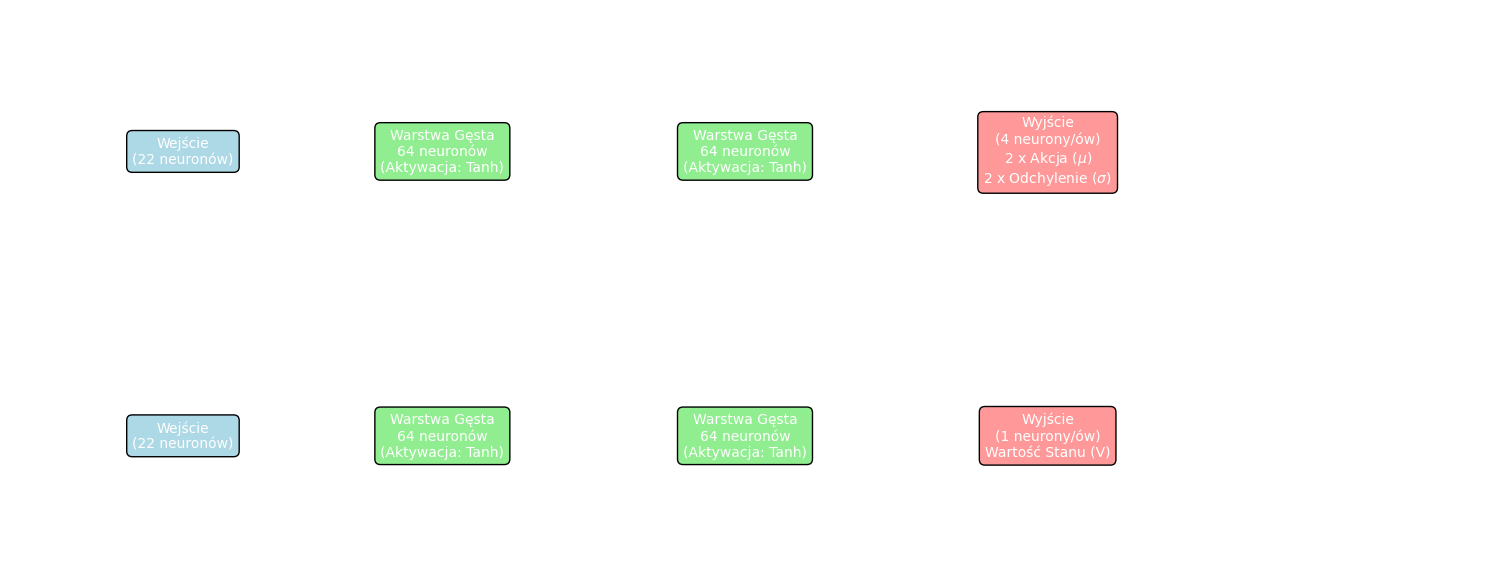

In [14]:
draw_architecture("Arch_1_Default_Tanh", OBS_SIZE, [64, 64], ACT_OUT_SIZE, [64, 64], VAL_OUT_SIZE, "Tanh", "arch_1_default.jpg")


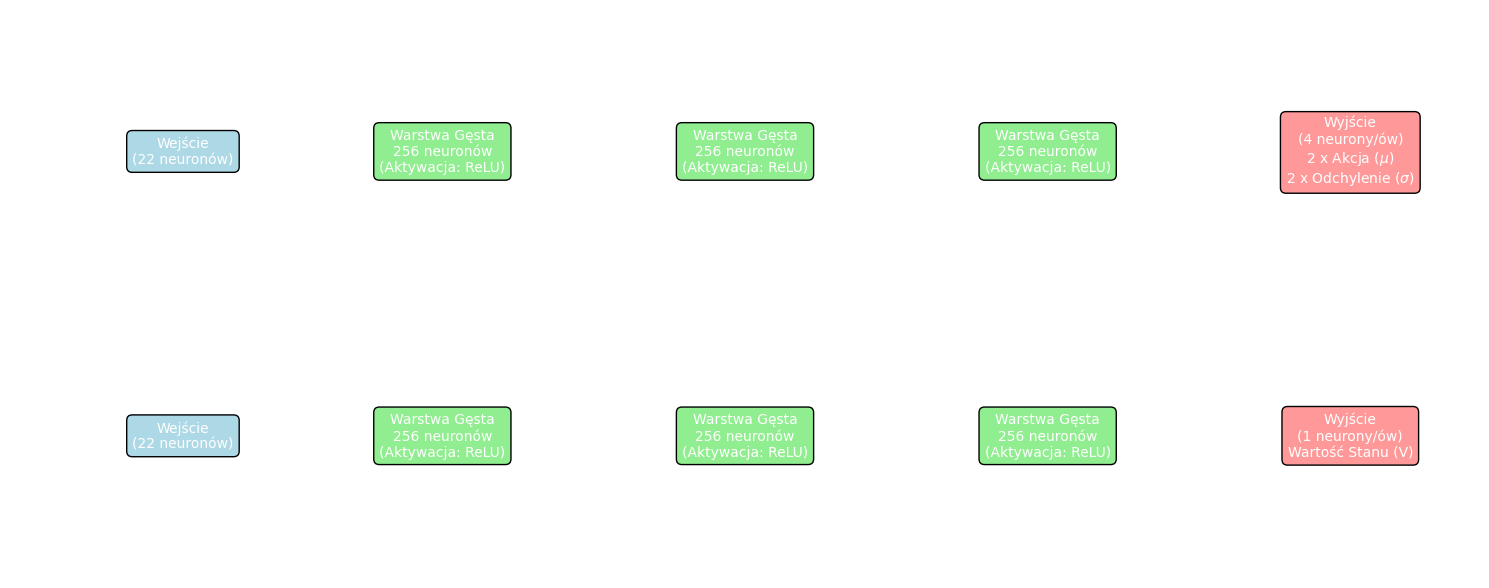

In [15]:
draw_architecture("Arch_2_Deep_ReLU", OBS_SIZE, [256, 256, 256], ACT_OUT_SIZE, [256, 256, 256], VAL_OUT_SIZE, "ReLU", "arch_2_deep.jpg")


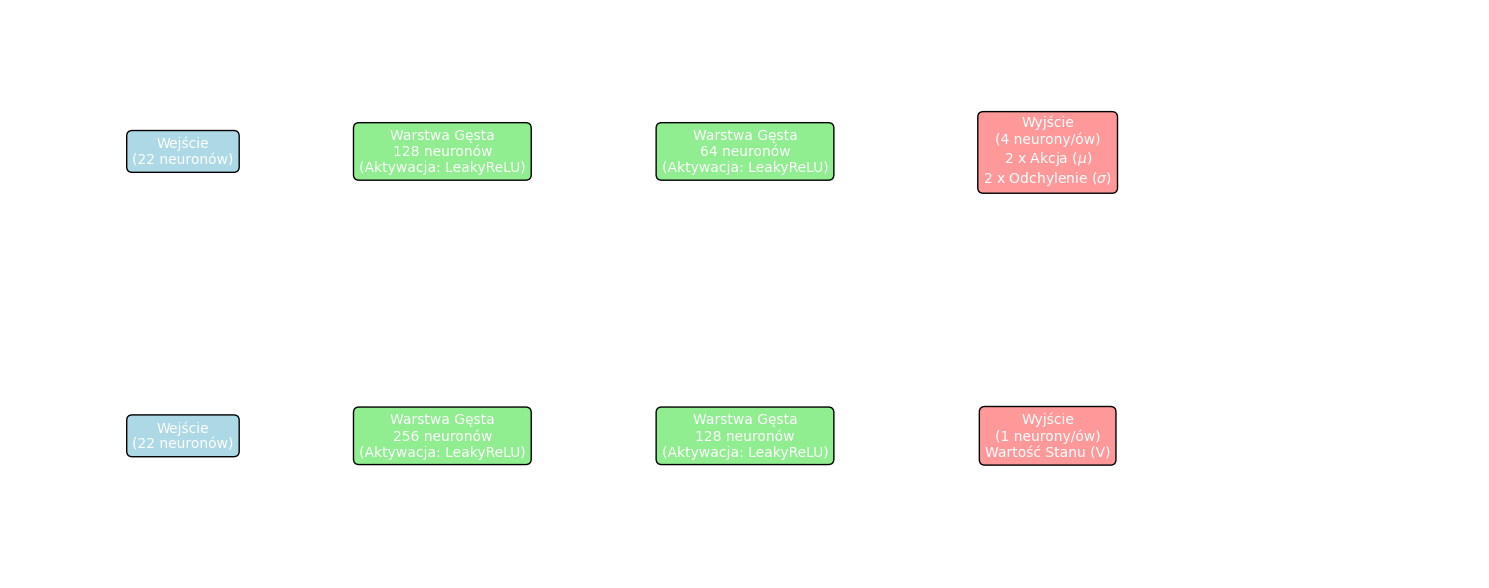

In [16]:
draw_architecture("Arch_3_Asymmetric_LeakyReLU", OBS_SIZE, [128, 64], ACT_OUT_SIZE, [256, 128], VAL_OUT_SIZE, "LeakyReLU", "arch_3_asymmetric.jpg")


In [12]:
import os
import io
import zipfile
import numpy as np
import pygame
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

def test_best_model(det=True, n_episodes=5, rock_every=200, player_size=15,
                    rock_size=15, target_size=15, rock_mass=0.75, gravity=450,
                    pickaxe_length=50, swing_power=650):

    env = Climber(render_mode='human', rock_every=rock_every, player_size=player_size,
                  rock_size=rock_size, target_size=target_size, rock_mass=rock_mass,
                  gravity=gravity, pickaxe_length=pickaxe_length, swing_power=swing_power)
    venv = DummyVecEnv([lambda: env])

    if os.path.exists("vec_normalize.pkl"):
        try:
            venv = VecNormalize.load("vec_normalize.pkl", venv)
            venv.training = False
            venv.norm_reward = False
        except Exception as e:
            print(f"Błąd ładowania: {e}")

    model_path = "best_climber_model.zip"

    try:
        model = PPO.load(model_path, env=venv)
    except:
        model = PPO("MlpPolicy", venv, verbose=0)
        try:
            with zipfile.ZipFile(model_path, 'r') as archive:
                with archive.open('policy.pth') as weights_file:
                    buffer = io.BytesIO(weights_file.read())
                    state_dict = torch.load(buffer, map_location="cpu", weights_only=False)
                    model.policy.load_state_dict(state_dict)
        except Exception as e:
            print(f"Błąd: {e}")
            return None

    all_episode_rewards = []
    running = True

    for ep in range(n_episodes):
        if not running:
            break

        obs = venv.reset()
        env.render()
        episode_reward = 0.0
        done = False

        while not done and running:
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    running = False

            if not running:
                break

            action, _states = model.predict(obs, deterministic=det)
            obs, reward, dones, info = venv.step(action)

            episode_reward += reward[0]
            done = dones[0]

            env.render()

        all_episode_rewards.append(episode_reward)
        print(f"Epizod {ep+1} (Det={det}) | Nagroda: {episode_reward:.2f}")

    env.close()

    if all_episode_rewards:
        return np.mean(all_episode_rewards)
    return None



In [13]:
mean_reward_det = test_best_model(det=True, n_episodes=5)
print(f"\nŚrednia nagroda (Deterministyczny): {mean_reward_det:.2f}")

mean_reward_stoch = test_best_model(det=False, n_episodes=5)
print(f"Średnia nagroda (Niedeterministyczny/Eksploracja): {mean_reward_stoch:.2f}")

C:\Users\kacpe\PycharmProjects\inteligencja_obliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


GAME LOST - hit_rock
Epizod 1 (Det=True) | Nagroda: 118.33
GAME LOST - hit_rock
Epizod 2 (Det=True) | Nagroda: 7.77
GAME LOST - hit_rock
Epizod 3 (Det=True) | Nagroda: 60.14
GAME LOST - hit_rock
Epizod 4 (Det=True) | Nagroda: 87.47
GAME LOST - hit_rock
Epizod 5 (Det=True) | Nagroda: 104.34

Średnia nagroda (Deterministyczny): 75.61
GAME WON - hit_target
Epizod 1 (Det=False) | Nagroda: 138.49
GAME WON - hit_target
Epizod 2 (Det=False) | Nagroda: 142.68
GAME WON - hit_target
Epizod 3 (Det=False) | Nagroda: 142.81
GAME LOST - hit_rock
Epizod 4 (Det=False) | Nagroda: 44.86
GAME WON - hit_target
Epizod 5 (Det=False) | Nagroda: 136.22
Średnia nagroda (Niedeterministyczny/Eksploracja): 121.01


### Wnioski
Z powyższego testu wynika, że agent radzi sobie gorzej względem agenta, który zachowuje się niedeterministycznie, Zdarzają się Epizody, w których nagroda jest bardzo niska - mogą zdarzać się jeszcze sytuacje, których agent nie rozumieje, zachowując się deterministycznie, co znaczy, że nie odkrył poprawnego wyjścia z danej sytuacji. Natomiast agent niedeterministyczny radzi sobie całkiem dobrze, udaje mu się nawet wygrać grę